# ImageNet L0: Semantic Object vs Matched Random Whole-Image

This notebook matches each semantic object row (`fix_nonmask`) to the same image's whole-image random row (`global`) at the nearest available support fraction.

- `object_ratio`: actual semantic object support fraction from `fix_nonmask`.
- `matched_ratio`: nearest available whole-image random support fraction from `{1/32, 1/16, 1/8, 1/4, 1/2, 1}`.
- The left histogram answers the question: if the semantic object result is safe, is the same image's matched whole-image random result also safe, unsafe, or unknown?
- `unknown` corresponds to rows that are neither `sat` nor `unsat` (for example, timeouts).


In [24]:
import logging
import os
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

FORCE_TEX = True
BASE_FONT_SIZE = 16
AXIS_LABEL_SIZE = 18
AXIS_TITLE_SIZE = 18
TICK_LABEL_SIZE = 14
LEGEND_FONT_SIZE = 13
VALUE_LABEL_FONT_SIZE = 13
DEFAULT_FIGSIZE = (8.6, 4.4)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results" / "vggnet16" / "all_k_vggnet16.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the XAIV project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
PLOT_DIR = PROJECT_ROOT / "plots" / "5.5.1_L0"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = PLOT_DIR / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)


@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


@lru_cache(maxsize=2)
def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print(
            "LaTeX was requested but the current environment cannot compile a minimal "
            "TeX document. Falling back to Matplotlib serif text."
        )

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "Nimbus Roman",
            "STIXGeneral",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": AXIS_TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "hatch.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


configure_plot_style()

CSV_PATH = PROJECT_ROOT / "results" / "vggnet16" / "all_k_vggnet16.csv"

BUCKET_LABELS = ["(0,1/32]", "(1/32,1/16]", "(1/16,1/8]", "(1/8,1/4]", "(1/4,1/2]", "(1/2,1]"]
RATIO_TO_BUCKET = {
    1 / 32: "(0,1/32]",
    1 / 16: "(1/32,1/16]",
    1 / 8: "(1/16,1/8]",
    1 / 4: "(1/8,1/4]",
    1 / 2: "(1/4,1/2]",
    1.0: "(1/2,1]",
}
RESULT_ORDER = ["safe", "unknown", "unsafe"]
PLOT_ORDER = ["Safe", "Unknown", "Unsafe"]
OUTCOME_STYLE = {
    "Safe": {"facecolor": "#111111", "hatch": ""},
    "Unknown": {"facecolor": "white", "hatch": "///"},
    "Unsafe": {"facecolor": "#B22222", "hatch": "xx"},
}
TEXT_COLOR = {
    "Safe": "white",
    "Unknown": "black",
    "Unsafe": "white",
}


def outcome_legend_handles():
    return [
        Patch(
            facecolor=OUTCOME_STYLE[outcome]["facecolor"],
            edgecolor="black",
            hatch=OUTCOME_STYLE[outcome]["hatch"],
            label=outcome,
        )
        for outcome in PLOT_ORDER
    ]


def annotate_stack_labels(ax, bars, values, bottoms, outcome):
    for bar, value, bottom in zip(bars, values, bottoms):
        if value <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + value / 2,
            f"{int(value)}",
            ha="center",
            va="center",
            fontsize=VALUE_LABEL_FONT_SIZE,
            color=TEXT_COLOR[outcome],
        )


def canon_result(value):
    text = str(value).lower()
    if "unsat" in text:
        return "safe"
    if "sat" in text:
        return "unsafe"
    return "unknown"


def nearest_ratio(value, candidates):
    value = float(value)
    candidates = np.asarray(candidates, dtype=float)
    return float(candidates[np.abs(candidates - value).argmin()])


df = pd.read_csv(CSV_PATH)

for col in ["k", "eps", "total", "segment_index", "num_changed", "percent_changed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["image", "tag", "model", "result"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df = df[df["tag"].isin(["fix_nonmask", "global"])].copy()
df = df.dropna(subset=["total", "num_changed"]).copy()
df["result_cat"] = df["result"].apply(canon_result)
df["support_ratio"] = df["num_changed"] / df["total"]

key_cols = [col for col in ["model", "image", "eps", "total"] if col in df.columns]

object_df = (
    df[df["tag"] == "fix_nonmask"]
    .copy()
    .rename(
        columns={
            "support_ratio": "object_ratio",
            "result": "object_result_raw",
            "result_cat": "object_result",
            "num_changed": "object_num_changed",
            "percent_changed": "object_percent_changed",
            "k": "object_k",
        }
    )
)

global_df = (
    df[df["tag"] == "global"]
    .copy()
    .rename(
        columns={
            "support_ratio": "global_ratio",
            "result": "whole_image_result_raw",
            "result_cat": "whole_image_result",
            "num_changed": "whole_image_num_changed",
            "percent_changed": "whole_image_percent_changed",
            "k": "whole_image_k",
        }
    )
)

global_df = global_df.sort_values(key_cols + ["global_ratio"]).drop_duplicates(
    subset=key_cols + ["global_ratio"],
    keep="first",
)

available_global_ratios = np.array(sorted(global_df["global_ratio"].dropna().unique()), dtype=float)
object_df["matched_ratio"] = object_df["object_ratio"].apply(lambda value: nearest_ratio(value, available_global_ratios))

merge_cols = key_cols + [
    "global_ratio",
    "whole_image_k",
    "whole_image_result_raw",
    "whole_image_result",
    "whole_image_num_changed",
    "whole_image_percent_changed",
]
paired = object_df.merge(
    global_df[merge_cols].rename(columns={"global_ratio": "matched_ratio"}),
    on=key_cols + ["matched_ratio"],
    how="left",
    validate="many_to_one",
)

if paired["whole_image_result"].isna().any():
    missing = int(paired["whole_image_result"].isna().sum())
    raise ValueError(f"Missing matched whole-image rows for {missing} object rows.")

paired["match_kind"] = np.where(
    np.isclose(paired["object_ratio"], paired["matched_ratio"]),
    "exact bucket",
    "nearest bucket",
)
paired["ratio_bucket"] = pd.Categorical(
    paired["matched_ratio"].map(RATIO_TO_BUCKET),
    categories=BUCKET_LABELS,
    ordered=True,
)
paired["same_outcome"] = paired["object_result"] == paired["whole_image_result"]

safe_pairs = paired[paired["object_result"] == "safe"].copy()

safe_object_rows = (
    safe_pairs[
        key_cols
        + [
            "segment_index",
            "object_k",
            "object_num_changed",
            "object_percent_changed",
            "object_ratio",
            "matched_ratio",
            "ratio_bucket",
            "match_kind",
            "object_result_raw",
            "object_result",
            "whole_image_result",
        ]
    ]
    .sort_values(["matched_ratio", "object_ratio", "image", "segment_index"])
    .reset_index(drop=True)
)

safe_global_rows = (
    safe_pairs[
        key_cols
        + [
            "whole_image_k",
            "whole_image_num_changed",
            "whole_image_percent_changed",
            "matched_ratio",
            "ratio_bucket",
            "match_kind",
            "whole_image_result_raw",
            "whole_image_result",
            "object_ratio",
            "object_result",
        ]
    ]
    .sort_values(["matched_ratio", "object_ratio", "image"])
    .reset_index(drop=True)
)

safe_outcome_counts = (
    safe_pairs.groupby(["ratio_bucket", "whole_image_result"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=BUCKET_LABELS, fill_value=0)
    .reindex(columns=RESULT_ORDER, fill_value=0)
)

safe_ratio_summary = (
    safe_pairs.groupby("ratio_bucket", observed=False)
    .agg(
        matched_ratio=("matched_ratio", "first"),
        min_object_ratio=("object_ratio", "min"),
        median_object_ratio=("object_ratio", "median"),
        max_object_ratio=("object_ratio", "max"),
        object_safe_total=("image", "size"),
        exact_bucket_matches=("match_kind", lambda values: int((pd.Series(values) == "exact bucket").sum())),
        nearest_bucket_matches=("match_kind", lambda values: int((pd.Series(values) == "nearest bucket").sum())),
    )
    .reindex(BUCKET_LABELS)
)
safe_ratio_summary = safe_ratio_summary.join(safe_outcome_counts)
safe_ratio_summary["whole_image_not_safe"] = safe_ratio_summary["unknown"] + safe_ratio_summary["unsafe"]
safe_ratio_summary["whole_image_safe_share"] = (
    safe_ratio_summary["safe"] / safe_ratio_summary["object_safe_total"].replace(0, np.nan)
)
safe_ratio_summary = safe_ratio_summary.reset_index(names="ratio_bucket")

object_counts = (
    paired.groupby(["ratio_bucket", "object_result"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=BUCKET_LABELS, fill_value=0)
    .reindex(columns=RESULT_ORDER, fill_value=0)
)
whole_image_counts = (
    paired.groupby(["ratio_bucket", "whole_image_result"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=BUCKET_LABELS, fill_value=0)
    .reindex(columns=RESULT_ORDER, fill_value=0)
)

comparison_summary = pd.concat(
    {
        "Object": object_counts,
        "Whole image": whole_image_counts,
    },
    names=["domain", "ratio_bucket"],
).reset_index()
comparison_summary = comparison_summary[["ratio_bucket", "domain", *RESULT_ORDER]]

safe_object_csv = PLOT_DIR / "imagenet_safe_object_rows_with_full_object_ratio.csv"
safe_global_csv = PLOT_DIR / "imagenet_safe_global_rows_with_full_object_ratio.csv"
safe_ratio_csv = PLOT_DIR / "imagenet_safe_full_object_ratios.csv"

safe_object_rows.to_csv(safe_object_csv, index=False)
safe_global_rows.to_csv(safe_global_csv, index=False)
safe_ratio_summary.to_csv(safe_ratio_csv, index=False)

print(f"Using CSV: {CSV_PATH}")
print(f"Paired object rows: {len(paired)}")
print(f"Exact bucket matches: {(paired['match_kind'] == 'exact bucket').sum()}")
print(f"Nearest bucket matches: {(paired['match_kind'] == 'nearest bucket').sum()}")
print(f"Object-safe rows: {len(safe_pairs)}")
print(f"Saved: {safe_object_csv}")
print(f"Saved: {safe_global_csv}")
print(f"Saved: {safe_ratio_csv}")


LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
Using CSV: /Users/zd3504phd/Desktop/XAIV/results/vggnet16/all_k_vggnet16.csv
Paired object rows: 1086
Exact bucket matches: 887
Nearest bucket matches: 199
Object-safe rows: 486
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_safe_object_rows_with_full_object_ratio.csv
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_safe_global_rows_with_full_object_ratio.csv
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_safe_full_object_ratios.csv


In [25]:
print("Safe object -> matched whole-image outcome counts by nearest bucket:")
display(safe_ratio_summary)

print("Object vs matched whole-image outcome counts across all rows:")
display(comparison_summary)


Safe object -> matched whole-image outcome counts by nearest bucket:


,ratio_bucket,matched_ratio,min_object_ratio,median_object_ratio,max_object_ratio,object_safe_total,exact_bucket_matches,nearest_bucket_matches,safe,unknown,unsafe,whole_image_not_safe,whole_image_safe_share
0,"(0,1/32]",0.03125,0.031250,0.031250,0.031250,87,87,0,87,0,0,0,1.000000
1,"(1/32,1/16]",0.06250,0.062500,0.062500,0.062500,87,87,0,87,0,0,0,1.000000
2,"(1/16,1/8]",0.12500,0.125000,0.125000,0.125000,87,87,0,87,0,0,0,1.000000
3,"(1/8,1/4]",0.25000,0.250000,0.250000,0.250000,86,86,0,86,0,0,0,1.000000
4,"(1/4,1/2]",0.50000,0.376953,0.500000,0.731684,116,76,40,109,7,0,7,0.939655
5,"(1/2,1]",1.00000,0.768734,0.831354,0.950793,23,0,23,4,19,0,19,0.173913


Object vs matched whole-image outcome counts across all rows:


,ratio_bucket,domain,safe,unknown,unsafe
0,"(0,1/32]",Object,87,0,94
1,"(1/32,1/16]",Object,87,0,94
2,"(1/16,1/8]",Object,87,0,94
3,"(1/8,1/4]",Object,86,0,97
4,"(1/4,1/2]",Object,116,9,136
5,"(1/2,1]",Object,23,24,52
6,"(0,1/32]",Whole image,87,0,94
7,"(1/32,1/16]",Whole image,87,0,94
8,"(1/16,1/8]",Whole image,87,0,94
9,"(1/8,1/4]",Whole image,86,0,97


Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_semantic_vs_matched_random_histograms.pdf
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_semantic_vs_matched_random_histograms.png


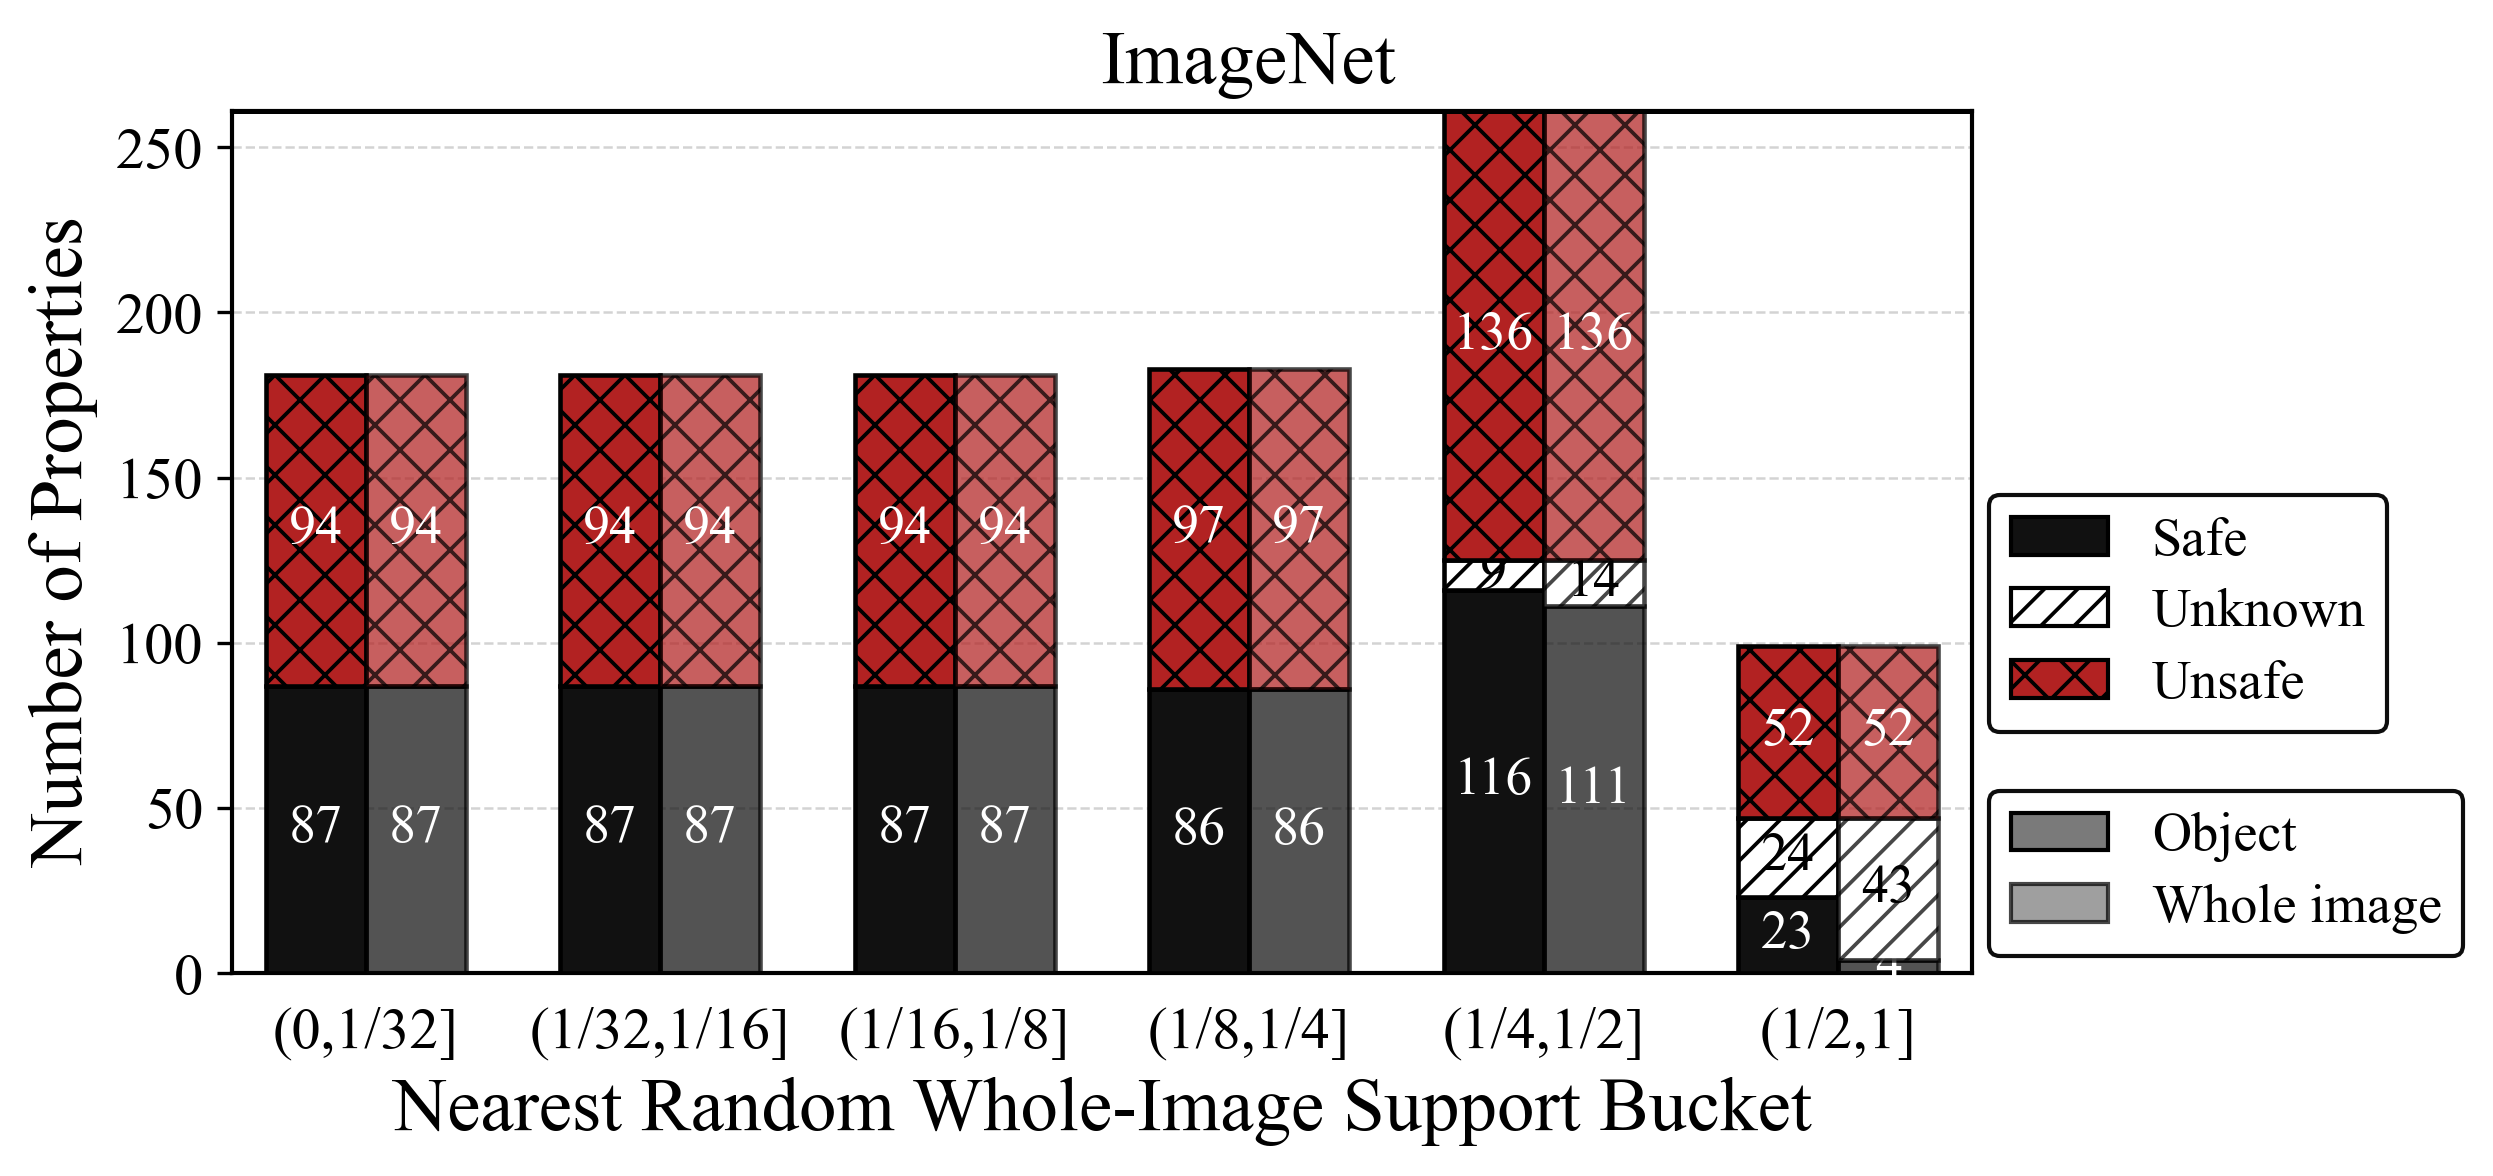

In [27]:
x = np.arange(len(BUCKET_LABELS))
width = 0.34
domain_specs = [
    ("Object", -width / 2, 1.0),
    ("Whole image", width / 2, 0.72),
]

totals_by_domain = []
for domain, _, _ in domain_specs:
    domain_frame = (
        comparison_summary[comparison_summary["domain"] == domain]
        .set_index("ratio_bucket")
        .reindex(BUCKET_LABELS)[RESULT_ORDER]
        .fillna(0)
    )
    totals_by_domain.append(domain_frame.sum(axis=1).to_numpy(dtype=float))

ymax = max(int(np.max(np.concatenate(totals_by_domain))), 1)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE, dpi=300)
fig.suptitle("ImageNet", fontsize=AXIS_TITLE_SIZE, y=0.9)


for domain, offset, alpha in domain_specs:
    domain_frame = (
        comparison_summary[comparison_summary["domain"] == domain]
        .set_index("ratio_bucket")
        .reindex(BUCKET_LABELS)[RESULT_ORDER]
        .fillna(0)
    )
    bottom = np.zeros(len(BUCKET_LABELS), dtype=float)
    for outcome in PLOT_ORDER:
        values = domain_frame[outcome.lower()].to_numpy(dtype=float)
        style = OUTCOME_STYLE[outcome]
        bars = ax.bar(
            x + offset,
            values,
            width=width,
            bottom=bottom,
            color=style["facecolor"],
            edgecolor="black",
            linewidth=1.1,
            hatch=style["hatch"],
            alpha=alpha,
            zorder=3,
        )
        annotate_stack_labels(ax, bars, values, bottom, outcome)
        bottom = bottom + values

ax.axhline(ymax, color="black", linewidth=1.2, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(BUCKET_LABELS)
ax.set_ylabel("Number of Properties")
ax.set_xlabel("Nearest Random Whole-Image Support Bucket")
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.55)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(axis="x", length=0, pad=8)
ax.margins(x=0.02)
ax.set_ylim(0, ymax)

outcome_legend = ax.legend(
    handles=outcome_legend_handles(),
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=0.95,
    ncol=1,
    loc="lower left",
    bbox_to_anchor=(1.01, 0.28),
    borderaxespad=0.0,
    handlelength=1.8,
    borderpad=0.4,
    labelspacing=0.4,
)
ax.add_artist(outcome_legend)

domain_handles = [
    Patch(facecolor="#7A7A7A", edgecolor="black", alpha=1.0, label="Object"),
    Patch(facecolor="#7A7A7A", edgecolor="black", alpha=0.72, label="Whole image"),
]
ax.legend(
    handles=domain_handles,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=0.95,
    ncol=1,
    loc="lower left",
    bbox_to_anchor=(1.01, 0.02),
    borderaxespad=0.0,
    handlelength=1.8,
    borderpad=0.4,
    labelspacing=0.4,
)

fig.tight_layout()
pdf_path = PLOT_DIR / "imagenet_semantic_vs_matched_random_histograms.pdf"
png_path = PLOT_DIR / "imagenet_semantic_vs_matched_random_histograms.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

display(fig)
plt.close(fig)
